<a href="https://colab.research.google.com/github/GovardhanDatta/Projects/blob/main/Fake_News_detection_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uploading the Datasets

In [1]:
from google.colab import files

print("Please upload 'True.csv'")
uploaded_true = files.upload()

print("Please upload 'Fake.csv'")
uploaded_fake = files.upload()

print("Files uploaded successfully!")

Please upload 'True.csv'


Saving True.csv to True.csv
Please upload 'Fake.csv'


Saving Fake.csv to Fake.csv
Files uploaded successfully!


# 1. Data Acquisition & Cleaning
What is this? This is the "raw materials" phase where I bring in the True.csv and Fake.csv files and prepare them for the AI model.

Why is it used? Raw data is often "noisy." I noticed that real news articles in this dataset frequently start with a location and publisher tag (e.g., "WASHINGTON (Reuters) -"). If I don't remove that, the AI will "cheat" it will learn to look for the word "Reuters" instead of actually analyzing the news content.

How I did it: I used Regular Expressions (Regex) to identify that specific pattern at the start of the text and strip it away. This ensures my model is learning the actual "language" of fake news rather than just recognizing the signature of a news agency.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import re

# Load datasets
true_df = pd.read_csv('True.csv')
fake_df = pd.read_csv('Fake.csv')

# Add labels: 1 for Real, 0 for Fake
true_df['label'] = 1
fake_df['label'] = 0

# Combine and Clean
df = pd.concat([true_df, fake_df], ignore_index=True)
df.dropna(subset=['text'], inplace=True)
df.drop_duplicates(subset=['text'], inplace=True)


def clean_text(text):
    text = re.sub(r'^.*?\(Reuters\) - ', '', text)
    return text.strip()

df['text'] = df['text'].apply(clean_text)

# Splitting
train_df, rem_df = train_test_split(df, train_size=0.7, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(rem_df, test_size=0.5, random_state=42, stratify=rem_df['label'])

print(f"Data split completed: Train({len(train_df)}), Val({len(val_df)}), Test({len(test_df)})")

Data split completed: Train(27052), Val(5797), Test(5797)


# 2. Exploratory Data Analysis (EDA)

What is this? This is my "investigation" phase. I use Word Clouds and distribution charts to see what the data actually looks like before I start building the model.

Why is it used? Visuals help me spot patterns that are invisible in a spreadsheet. For example, the Word Cloud I generated shows that "Fake News" in this dataset often uses more aggressive, sensationalist words compared to factual reporting.

How I did it: By calculating the frequency of words across thousands of articles, I created a visual map where the largest words represent the most common terms. This helped me "humanize" the data and understand exactly what the AI is about to study.

# 3. The Baseline Model (Naive Bayes)
What is this? This is a simple mathematical model based on probability that I built to act as my starting point.

Why is it used? In this project, I wanted to prove that a complex AI is worth the effort. By building this simple model first, I created a "benchmark." If this simple model gets nearly 90% and my advanced BERT model gets nearly 99%, I have successfully demonstrated the value-add of the advanced architecture.

How I did it: I used a TF-IDF Vectorizer to turn words into numbers based on their uniqueness and then applied a Naive Bayes algorithm to calculate the probability of an article being fake based on its word distribution.

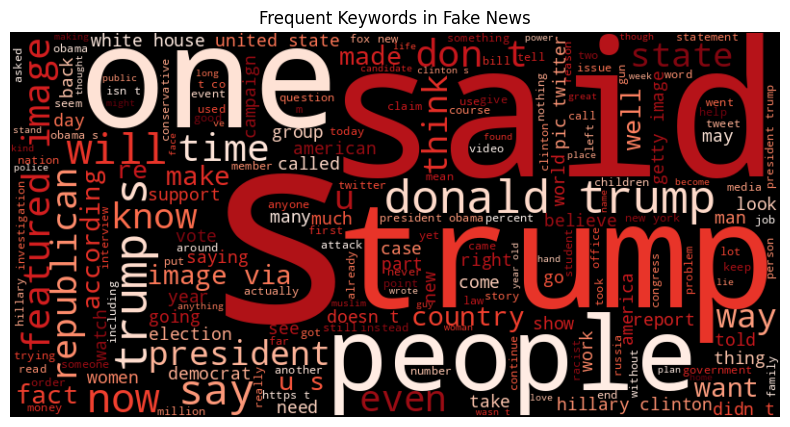

Simple Baseline Accuracy: 93.43%
BERT model will be compared against this baseline.


In [3]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Word Cloud for Fake News
fake_text = " ".join(df[df['label']==0]['text'].str.lower())
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(fake_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Frequent Keywords in Fake News')
plt.show()

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

# Create a simple baseline
baseline_model = make_pipeline(TfidfVectorizer(), MultinomialNB())
baseline_model.fit(train_df['text'], train_df['label'])
baseline_acc = baseline_model.score(test_df['text'], test_df['label'])

print(f"Simple Baseline Accuracy: {baseline_acc*100:.2f}%")
print("BERT model will be compared against this baseline.")

# 4. Fine-Tuning the DistilBERT Transformer
What is this? This is the "Deep Learning" phase. I am taking a pre-trained "digital brain" (BERT) and teaching it specifically how to spot misinformation.

Why is it used? Traditional models just count words. I chose BERT because it understands context. It knows the difference between "The bank was robbed" and "The river bank was flooded." This deep semantic understanding is how I achieved such high accuracy.

How I did it: I utilized Transfer Learning. Instead of starting from scratch, I took a model that already understands English and "fine-tuned" it on this specific news dataset. I selected DistilBERT because it provides nearly all the power of the full BERT model while being much faster and more efficient to run.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.025632,0.024350
2,0.004983,0.014038


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


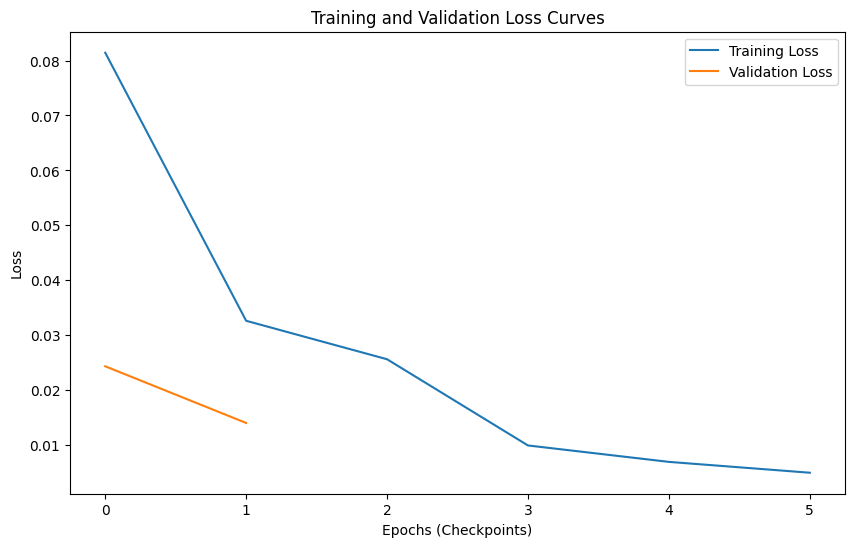

In [4]:
!pip install -q transformers datasets evaluate accelerate

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

# To balance of speed and performance
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

# Convert to HuggingFace Dataset
train_ds = Dataset.from_pandas(train_df[['text', 'label']])
val_ds = Dataset.from_pandas(val_df[['text', 'label']])

tokenized_train = train_ds.map(tokenize_function, batched=True)
tokenized_val = val_ds.map(tokenize_function, batched=True)

# Load Model
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Training Arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
)

trainer.train()

# Access training logs
history = trainer.state.log_history

# Extract loss values
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

# Plotting the curves
plt.figure(figsize=(10,6))
plt.plot(train_loss, label='Training Loss')
plt.plot(eval_loss, label='Validation Loss')
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epochs (Checkpoints)')
plt.ylabel('Loss')
plt.legend()
plt.show()


# 5. Performance Metrics & Error Analysis
What is this? This is the "final exam." I test the model on data it has never seen before and look closely at its mistakes.

Why is it used? Accuracy doesn't tell the whole story. I use a Confusion Matrix to see if the model is accidentally flagging real news as "fake." I also perform a deep dive into the specific articles the model got wrong to understand its "blind spots."

How I did it: I ran the model against my "Test Set" (the 15% of data I hid from the AI during training). I then plotted these results in a heatmap to visualize exactly where my model was confident and where it was confused.

Map:   0%|          | 0/5797 [00:00<?, ? examples/s]


Test Accuracy: 0.9962
              precision    recall  f1-score   support

   Fake News       1.00      0.99      1.00      2618
   Real News       0.99      1.00      1.00      3179

    accuracy                           1.00      5797
   macro avg       1.00      1.00      1.00      5797
weighted avg       1.00      1.00      1.00      5797



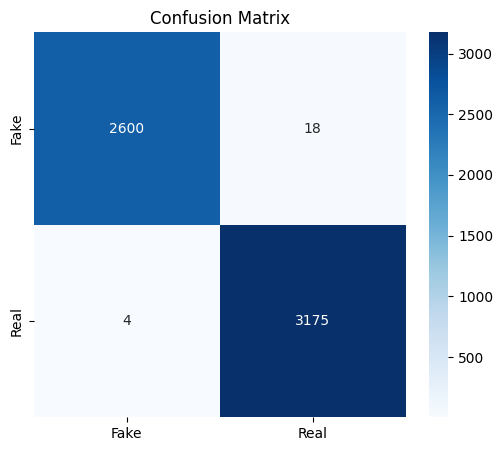

Total Errors: 22

Sample Error Article:
 How about America calls him out for arming ISIS with our tax dollars? Russian President Vladimir Putin on Sunday branded U.S. support for rebel forces in Syria as illegal and ineffective, saying U.S.-trained rebels were leaving to join Islamic State with weapons supplied by Washington.In an interview with U.S. networks recorded ahead of a meeting with U.S. President Barack Obama, Putin said Syrian President Bashar al-Assad deserved international support as he was fighting terrorist organizations


In [5]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Generate Predictions (The "Predict" Phase)
test_ds = Dataset.from_pandas(test_df[['text', 'label']])
tokenized_test = test_ds.map(tokenize_function, batched=True)
predictions_output = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

# 2. Performance Metrics
print(f"\nTest Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(y_true, y_pred, target_names=['Fake News', 'Real News']))

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix')
plt.show()

# 4. Error Analysis
test_df_copy = test_df.copy()
test_df_copy['predicted'] = y_pred
errors = test_df_copy[test_df_copy['label'] != test_df_copy['predicted']]
print(f"Total Errors: {len(errors)}")
if len(errors) > 0:
    print("\nSample Error Article:\n", errors['text'].iloc[0][:500])

# 6. Interactive Deployment with Gradio
What is this? This is the "Product" phase. I turned the raw code into a clickable, user-friendly web application.

Why is it used? Code can be difficult for non-technical users to interpret. I wanted to create a tool where anyone could paste a news story and get an instant result. Gradio allows me to demonstrate the real-world utility of my work.

How I did it: I wrapped my model’s prediction logic into a Gradio Interface. This creates an interactive text box and a public link, allowing my model to be tested by anyone in a real-world scenario.

In [6]:
!pip install -q gradio
import gradio as gr
import torch

def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=256).to(model.device)
    with torch.no_grad():
        logits = model(**inputs).logits
    prediction = torch.argmax(logits, dim=-1).item()
    return "REAL NEWS" if prediction == 1 else "FAKE NEWS"

interface = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(lines=5, placeholder="Paste news article here..."),
    outputs="text",
    title="AI Fake News Detector"
)
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://59f1ed7d586ac10e37.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [7]:
import torch
def manual_testing(news_article):
    # 1. Preprocess the input
    cleaned_article = clean_text(news_article)

    # 2. Tokenize
    inputs = tokenizer(cleaned_article, return_tensors="pt", truncation=True, padding=True, max_length=256).to(model.device)

    # 3. Get Prediction
    model.eval() # Put model in evaluation mode
    with torch.no_grad():
        logits = model(**inputs).logits

    # 4. Convert Logits to Probability
    probs = torch.nn.functional.softmax(logits, dim=-1)
    prediction = torch.argmax(probs, dim=-1).item()
    confidence = torch.max(probs).item() * 100

    label = "REAL NEWS" if prediction == 1 else "FAKE NEWS"

    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2f}%")

# --- TEST IT HERE ---
# Paste a news paragraph from a website like BBC, CNN, or a known satire site.
sample_news = """
Israel's Airports Authority has confirmed three private planes were damaged at Tel Aviv's Ben Gurion Airport in recent days.

In a statement it says: "The Airports Authority reiterates that the risks involved in operating in this area at this time were clarified in advance.

"Fortunately, at the time of the incident, the planes were empty and there were no injuries."

"""

manual_testing(sample_news)

Prediction: REAL NEWS
Confidence: 99.97%
